<a href="https://colab.research.google.com/github/h1teshrawat/Portfolio/blob/main/pbl_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install opencv-python-headless scikit-learn matplotlib numpy


In [ ]:
from google.colab import files
import os

# Create a folder to store images
os.makedirs("images", exist_ok=True)

# Upload images manually
uploaded = files.upload()
for filename in uploaded.keys():
    with open(os.path.join("images", filename), "wb") as f:
        f.write(uploaded[filename])

Saving 17.jpg to 17.jpg
Saving 16.webp to 16.webp
Saving 15.webp to 15.webp
Saving 14.jpg to 14.jpg
Saving 13.jpg to 13.jpg
Saving 12.webp to 12.webp
Saving 11.webp to 11.webp
Saving 10.webp to 10.webp
Saving 9.webp to 9.webp
Saving 8.jpg to 8.jpg
Saving 7.jpg to 7.jpg
Saving 6.jpg to 6.jpg
Saving 5.webp to 5.webp
Saving 4.jpg to 4.jpg
Saving 3.jpeg to 3.jpeg
Saving 2.avif to 2.avif
Saving 1.webp to 1.webp


In [ ]:
import cv2
import numpy as np

def extract_color_histogram(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (128, 128))
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8],
                        [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

def load_images(folder):
    features = []
    image_paths = []
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(folder, filename)
            hist = extract_color_histogram(path)
            features.append(hist)
            image_paths.append(path)
    return np.array(features), image_paths

In [ ]:
from sklearn.cluster import KMeans

def cluster_images(features, n_clusters=3):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(features)
    return labels

In [ ]:
import matplotlib.pyplot as plt

def visualize_clusters(image_paths, labels, n_clusters):
    for cluster_id in range(n_clusters):
        print(f"\nCluster {cluster_id + 1}:")
        cluster_images = [path for path, label in zip(image_paths, labels) if label == cluster_id]
        for img_path in cluster_images:
            print(f" - {os.path.basename(img_path)}")

        fig, axs = plt.subplots(1, len(cluster_images), figsize=(15, 5))
        for i, img_path in enumerate(cluster_images):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axs[i].imshow(img)
            axs[i].axis('off')
        plt.suptitle(f'Cluster {cluster_id + 1}')
        plt.show()


Cluster 1:
 - 8.jpg
 - 13.jpg
 - 14.jpg


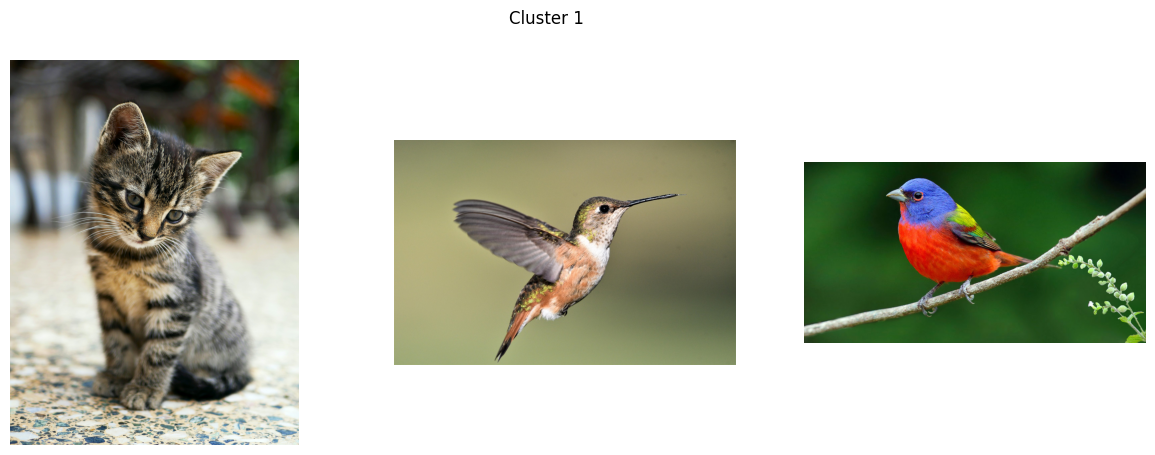


Cluster 2:
 - 6.jpg
 - 7.jpg


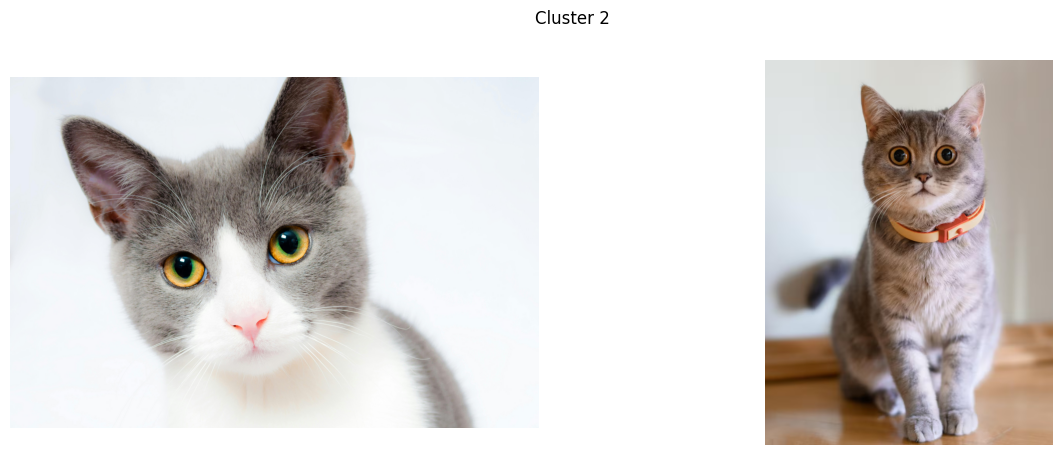


Cluster 3:
 - 4.jpg
 - 17.jpg
 - 3.jpeg


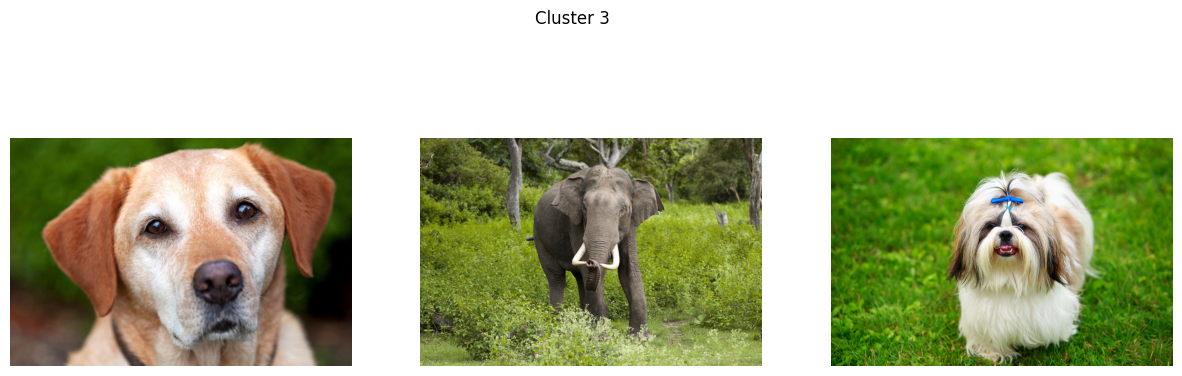

In [ ]:
# Load images and extract features
features, image_paths = load_images("images")

# Cluster images
labels = cluster_images(features, n_clusters=3)

# Visualize results
visualize_clusters(image_paths, labels, n_clusters=3)